<a href="https://colab.research.google.com/github/firdosealiya88-cpu/Oasis-Infobyte-Unemployment-Analysis/blob/main/Unemployment_Analysis_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Updated file path to look in the root folder
df = pd.read_csv('/Unemployment in India.csv')

# Shape inspection and null value check
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Drop rows with null values to clean data
df.dropna(inplace=True)

# Strip spaces from column names to avoid key errors
df.columns = df.columns.str.strip()

Dataset Shape: (768, 7)

Missing Values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [ ]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

# Create a Month column for trend tracking
df['Month'] = df['Date'].dt.strftime('%B')
print(df.dtypes)

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                                              object
dtype: object


In [ ]:
# Group data by Region and compute mean rates
region_analysis = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("--- Region-wise Average Unemployment Rate ---")
print(region_analysis.head(10))

# Group data by Month and compute mean rates
month_analysis = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("\n--- Month-wise Average Unemployment Rate ---")
print(month_analysis)

--- Region-wise Average Unemployment Rate ---
             Region  Estimated Unemployment Rate (%)
0    Andhra Pradesh                         7.477143
1             Assam                         6.428077
2             Bihar                        18.918214
3        Chandigarh                        15.991667
4      Chhattisgarh                         9.240357
5             Delhi                        16.495357
6               Goa                         9.274167
7           Gujarat                         6.663929
8           Haryana                        26.283214
9  Himachal Pradesh                        18.540357

--- Month-wise Average Unemployment Rate ---
        Month  Estimated Unemployment Rate (%)
0       April                        23.641569
1      August                         9.637925
2    December                         9.497358
3    February                         9.964717
4     January                         9.950755
5        July                         9.033

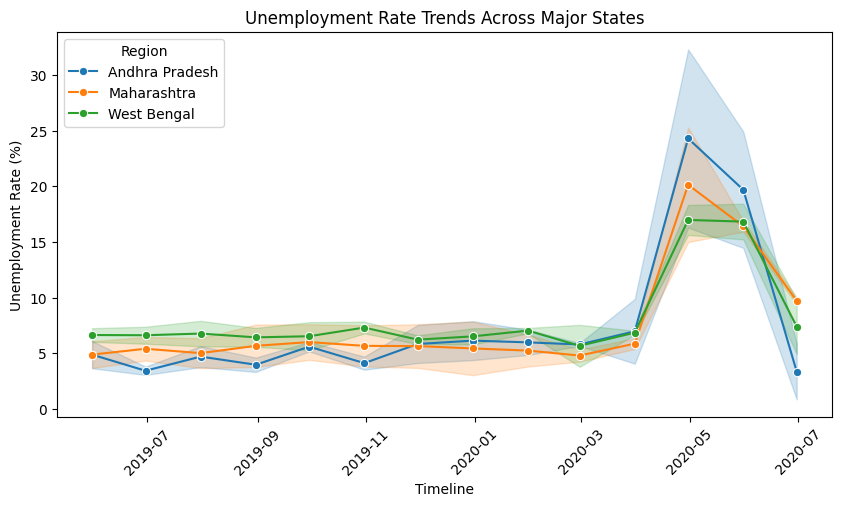

In [ ]:
plt.figure(figsize=(10, 5))

# Filtering 3 sample regions to keep the phone screen readable
major_states = df[df['Region'].isin(['Andhra Pradesh', 'Maharashtra', 'West Bengal'])]

sns.lineplot(data=major_states, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title('Unemployment Rate Trends Across Major States')
plt.xlabel('Timeline')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2487/1318362754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')


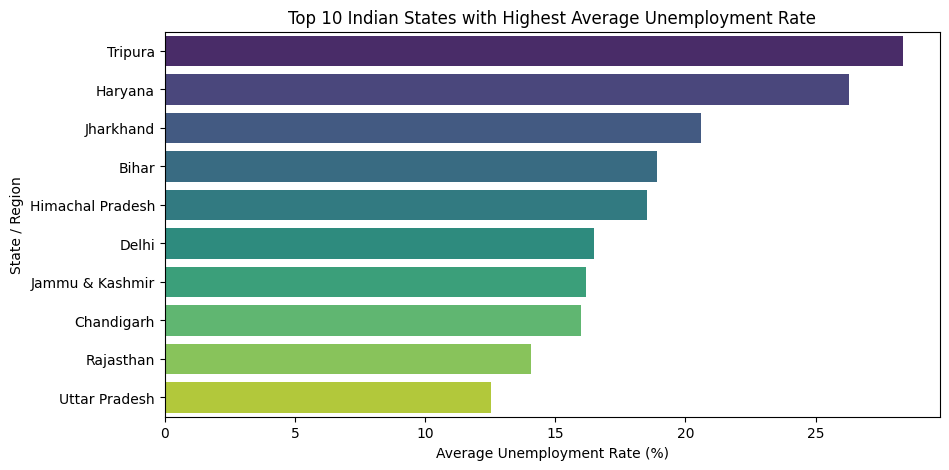

In [ ]:
plt.figure(figsize=(10, 5))
top_10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_10, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')
plt.title('Top 10 Indian States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.show()

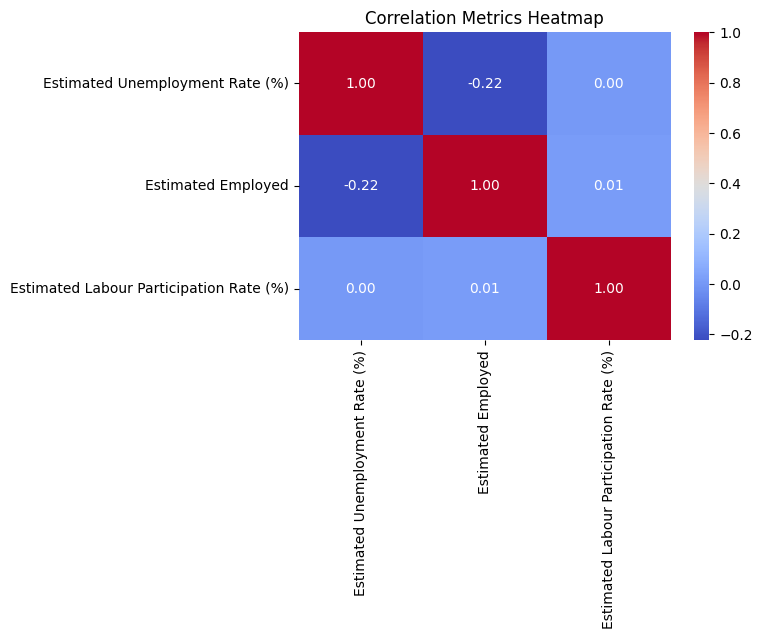

In [ ]:
plt.figure(figsize=(6, 4))
correlation_matrix = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Metrics Heatmap')
plt.show()

In [ ]:
# Segmenting data based on the lockdown baseline
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

print("--- Pre-COVID Era vs Post-COVID Era Analysis ---")
print("Pre-COVID Mean Unemployment Rate:", round(pre_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")
print("Post-COVID Mean Unemployment Rate:", round(post_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")

--- Pre-COVID Era vs Post-COVID Era Analysis ---
Pre-COVID Mean Unemployment Rate: 9.51 %
Post-COVID Mean Unemployment Rate: 17.77 %


Observation 1: A major surge in the unemployment rate occurs around May 2020 across all states due to the COVID-19 pandemic lockdown phase.

Observation 2: The correlation matrix shows a negative correlation (-0.22) between the Estimated Unemployment Rate and Estimated Employed metrics.

Observation 3: Average unemployment rates increased substantially in the post-COVID phase compared to the steady pre-COVID baseline period.